<a href="https://colab.research.google.com/github/krasnovaov81-coder/Case_DZ_Netology/blob/main/%D0%9A%D0%B5%D0%B9%D1%81_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%BA%D0%BE%D1%80%D1%80%D0%B5%D0%BB%D1%8F%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Учебный кейс: анализ корреляции**

*Шаблон для выполнения задания*

## **Описание данных**

[Ссылка](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors?utm_source=chatgpt.com$0) на данные.

В этом задании используется датасет Student Performance, содержащий информацию о факторах, которые могут влиять на успеваемость студентов.  

В данных представлены сведения о времени подготовки, посещаемости занятий, сне, физической активности, дополнительных занятиях и итоговых результатах экзамена.  

Каждая строка таблицы соответствует отдельному студенту, а признаки отражают различные аспекты учебного процесса и образа жизни.  

В рамках задания будут использоваться следующие числовые признаки:  

* `Hours_Studied` — количество часов подготовки в неделю;  
* `Attendance` — посещаемость занятий в процентах;  
* `Sleep_Hours` — среднее количество часов сна;  
* `Previous_Scores` — результаты предыдущих экзаменов;  
* `Tutoring_Sessions` — количество дополнительных занятий;  
* `Physical_Activity` — количество часов физической активности;  
* `Exam_Score` — итоговый балл экзамена.  

### **1. Импорт библиотек**

Импортируйте необходимые для работы библиотеки: `pandas`, `matplotlib.pyplot`, `seaborn`, `scipy.stats`.

In [ ]:
# Ваш код здесь
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# настройки отображения графиков
sns.set_theme(style="whitegrid")

### **2. Загрузка данных**

Скачайте датасет Student Performance и загрузите CSV-файл вручную. Загрузите датасет в формате CSV с помощью функции `pd.read_csv()`.

In [ ]:
# Ваш код здесь
df = pd.read_csv("/content/StudentPerformanceFactors.csv")

# Ваш код здесь: выведите первые строки
df.head()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

*Ваш вывод по первичному анализу данных (структура, пропуски, типы данных):*
>

В исходном датасете содержатся данные о 6607 студентах. Для анализа используются числовые признаки, относящиеся к подготовке, посещаемости, образу жизни и результатам экзамена.

### **3. Подготовка данных**

В этом задании будем использовать только числовые признаки. Отфильтруйте данных по нужным числовым столбцам, о которых говорилось в описании данных.

In [ ]:
# Ваш код здесь:
numeric_columns = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Exam_Score"
]

numeric_df = df[numeric_columns].copy()

numeric_df.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,23,84,7,73,0,3,67
1,19,64,8,59,2,4,61
2,24,98,7,91,2,4,74
3,29,89,8,98,1,4,71
4,19,92,6,65,3,4,70


*Ваш вывод о выбранных числовых признаках:*
>

В анализ включены следующие признаки:
Hours_Studied — количество часов подготовки;
Attendance — посещаемость;
Sleep_Hours — продолжительность сна;
Previous_Scores — предыдущие результаты;
Tutoring_Sessions — количество дополнительных занятий;
Physical_Activity — физическая активность;
Exam_Score — итоговый балл экзамена.
Все выбранные признаки имеют числовой тип.

### **4. Первичное знакомство с данными**

Изучите структуру данных:
* определите размер таблицы;
* проверьте типы данных;
* найдите количество пропусков;
* получите основные статистики.

In [ ]:
# Ваш код здесь: выведите размер таблица
print("Размер таблицы:", numeric_df.shape)

Размер таблицы: (6607, 7)


In [ ]:
# Ваш код здесь: выведите информацию о датасете с помощью info()
numeric_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Hours_Studied      6607 non-null   int64
 1   Attendance         6607 non-null   int64
 2   Sleep_Hours        6607 non-null   int64
 3   Previous_Scores    6607 non-null   int64
 4   Tutoring_Sessions  6607 non-null   int64
 5   Physical_Activity  6607 non-null   int64
 6   Exam_Score         6607 non-null   int64
dtypes: int64(7)
memory usage: 361.4 KB


In [ ]:
# Ваш код здесь: выведите количество пропусков
print("Количество пропусков:")
print(numeric_df.isna().sum())

Количество пропусков:
Hours_Studied        0
Attendance           0
Sleep_Hours          0
Previous_Scores      0
Tutoring_Sessions    0
Physical_Activity    0
Exam_Score           0
dtype: int64


In [ ]:
# Ваш код здесь: выведите базовые показатели через describe()
numeric_df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


*Ваш вывод по базовой статистике:*
>

В среднем студенты готовятся около 20 часов, посещают примерно 80% занятий и спят около 7 часов в сутки. Средний итоговый балл равен 67,24.

### **5. Расчёт корреляционной матрицы**

Рассчитайте матрицу корреляций между всеми числовыми признаками.
Определите:
* признаки с сильной положительной корреляцией;
* признаки со слабой корреляцией;
* есть ли отрицательные корреляции.

In [ ]:
# Ваш код здесь: выведите матрицу корреляций
correlation_matrix = numeric_df.corr()

print("Матрица корреляций:")
display(correlation_matrix.round(3))

Матрица корреляций:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000,-0.010,0.011,0.025,-0.014,0.005,0.445
Attendance,-0.010,1.000,-0.016,-0.020,0.014,-0.022,0.581
Sleep_Hours,0.011,-0.016,1.000,-0.022,-0.012,-0.000,-0.017
Previous_Scores,0.025,-0.020,-0.022,1.000,-0.013,-0.011,0.175
Tutoring_Sessions,-0.014,0.014,-0.012,-0.013,1.000,0.018,0.157
Physical_Activity,0.005,-0.022,-0.000,-0.011,0.018,1.000,0.028
Exam_Score,0.445,0.581,-0.017,0.175,0.157,0.028,1.000


*Ваш вывод по матрице корреляций:*
>

*   наиболее сильная положительная корреляция наблюдается между Attendance и Exam_Score: r=0.581;
*   заметная положительная корреляция есть между Hours_Studied и Exam_Score: r=0.445
*   слабая положительная связь наблюдается у Previous_Scores, Tutoring_Sessions и Physical_Activity;
*   корреляция Sleep_Hours с итоговым баллом практически отсутствует:
r=−0.017;
*   между большинством факторов, не связанных с Exam_Score, корреляции близки к нулю.


### **6. Визуализация корреляционной матрицы**
Постройте heatmap корреляционной матрицы.

Требования:
* подпишите график;
* отобразите коэффициенты корреляции;
* используйте цветовую палитру.

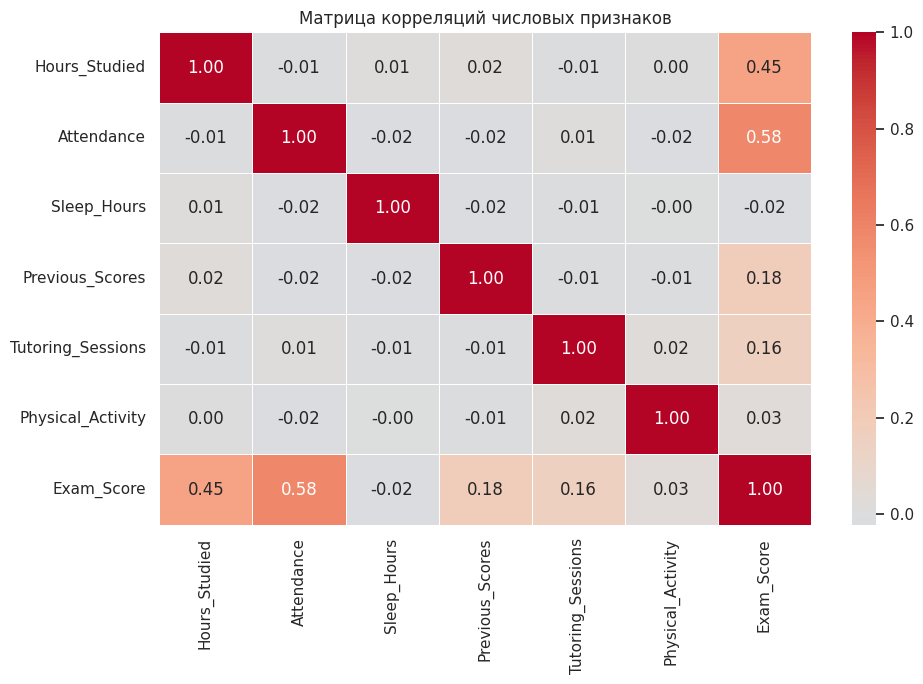

In [ ]:
# Ваш код здесь: постройте heatmap корреляционной матрицы
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Матрица корреляций числовых признаков")
plt.tight_layout()
plt.show()

*Ваш вывод по heatmap корреляционной матрицы:*
>

Heatmap показывает, что наиболее заметные связи с итоговым баллом имеют посещаемость и количество часов подготовки. Связь сна и физической активности с экзаменационным результатом визуально практически не выражена.

### **7. Анализ корреляции с итоговым баллом**    

Проанализируйте корреляцию признаков с Exam_Score.

Необходимо:
* отсортировать коэффициенты корреляции;
* определить признаки с наиболее сильной связью;
* построить столбчатую диаграмму.

In [ ]:
# Ваш код здесь: отсортируйте коэффициенты корреляции и определите признаки с наиболее сильной связью
exam_correlations = (
    correlation_matrix["Exam_Score"]
    .sort_values(ascending=False)
)

print("Корреляции с Exam_Score:")
print(exam_correlations.round(3))

features_correlations = exam_correlations.drop("Exam_Score")

print("Корреляции признаков с Exam_Score без самого Exam_Score:")
print(features_correlations.round(3))

Корреляции с Exam_Score:
Exam_Score           1.000
Attendance           0.581
Hours_Studied        0.445
Previous_Scores      0.175
Tutoring_Sessions    0.157
Physical_Activity    0.028
Sleep_Hours         -0.017
Name: Exam_Score, dtype: float64
Корреляции признаков с Exam_Score без самого Exam_Score:
Attendance           0.581
Hours_Studied        0.445
Previous_Scores      0.175
Tutoring_Sessions    0.157
Physical_Activity    0.028
Sleep_Hours         -0.017
Name: Exam_Score, dtype: float64


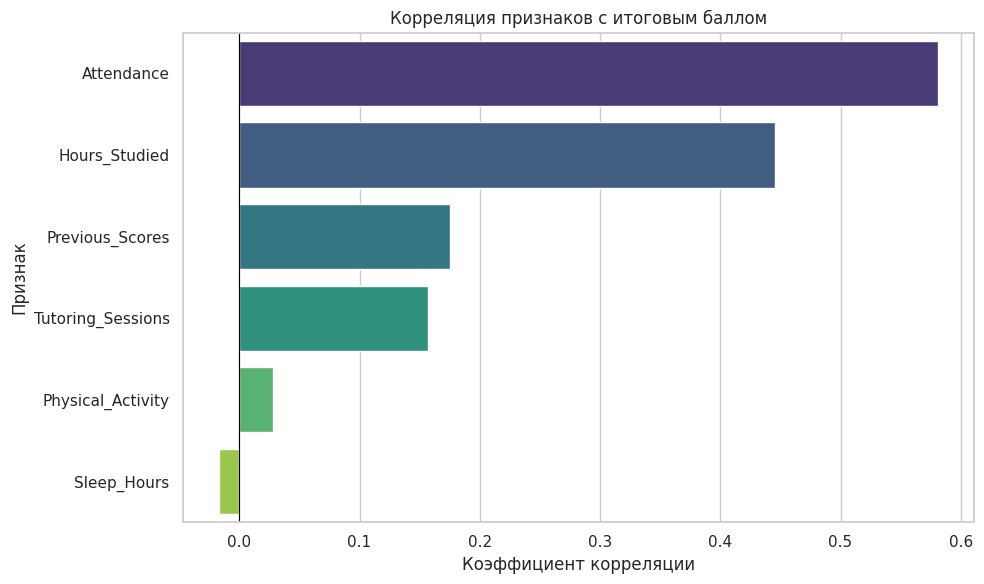

In [ ]:
# Ваш код здесь: постройте столбчатую диаграмма
plt.figure(figsize=(10, 6))

sns.barplot(
    x=features_correlations.values,
    y=features_correlations.index,
    hue=features_correlations.index,
    palette="viridis",
    legend=False
)

plt.title("Корреляция признаков с итоговым баллом")
plt.xlabel("Коэффициент корреляции")
plt.ylabel("Признак")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

*Ваш вывод по признакам и визуализации:*
- самый сильный фактор — посещаемость занятий;
- второй по силе фактор — количество часов подготовки;
- предыдущие результаты и дополнительные занятия имеют слабую положительную связь;
- физическая активность почти не связана с итоговым баллом;
- продолжительность сна не демонстрирует линейной связи с результатом экзамена.

### **8. Scatter-графики**
Постройте scatter-графики для следующих пар признаков:
* Hours_Studied и Exam_Score
* Attendance и Exam_Score
* Sleep_Hours и Exam_Score

После каждого графика сделайте краткий вывод.

Hours_Studied и Exam_Score

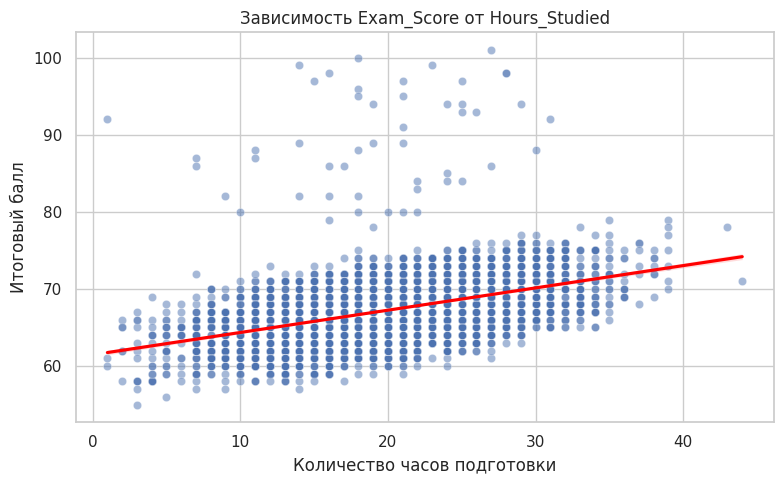

In [ ]:
# Ваш код здесь: постройте scatter-график для Hours_Studied и Exam_Score
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=numeric_df,
    x="Hours_Studied",
    y="Exam_Score",
    alpha=0.5
)

sns.regplot(
    data=numeric_df,
    x="Hours_Studied",
    y="Exam_Score",
    scatter=False,
    color="red"
)

plt.title("Зависимость Exam_Score от Hours_Studied")
plt.xlabel("Количество часов подготовки")
plt.ylabel("Итоговый балл")
plt.tight_layout()
plt.show()

*Ваш вывод по визуализации:*
>наблюдается умеренная положительная зависимость. В среднем студенты, которые тратят больше времени на подготовку, получают более высокие баллы. Однако точки заметно разбросаны, поэтому одной подготовки недостаточно для полного объяснения результата.

Attendance и Exam_Score

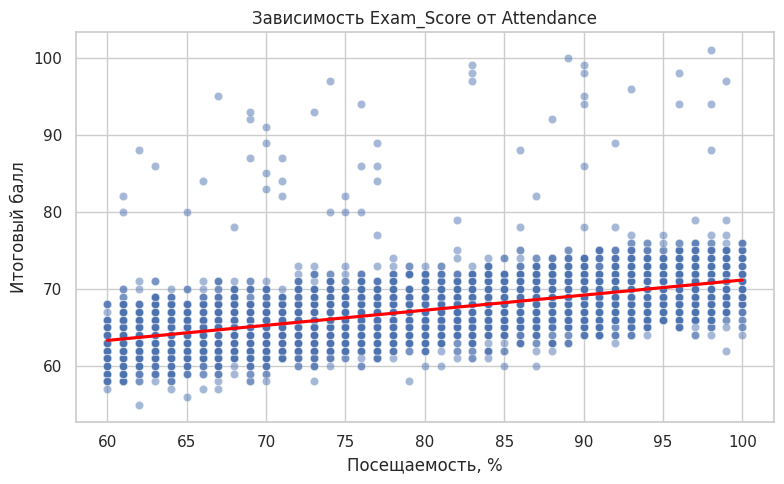

In [ ]:
# Ваш код здесь: постройте scatter-график для Attendance и Exam_Score
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=numeric_df,
    x="Attendance",
    y="Exam_Score",
    alpha=0.5
)

sns.regplot(
    data=numeric_df,
    x="Attendance",
    y="Exam_Score",
    scatter=False,
    color="red"
)

plt.title("Зависимость Exam_Score от Attendance")
plt.xlabel("Посещаемость, %")
plt.ylabel("Итоговый балл")
plt.tight_layout()
plt.show()

*Ваш вывод по визуализации:*
>посещаемость имеет наиболее сильную положительную связь с итоговым баллом среди рассмотренных признаков. При увеличении посещаемости значения Exam_Score в среднем также увеличиваются.

Sleep_Hours и Exam_Score

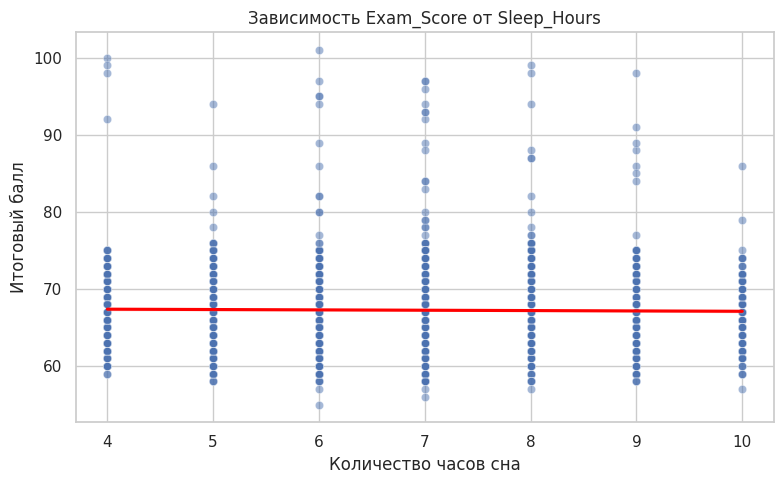

In [ ]:
# Ваш код здесь: постройте scatter-график для Sleep_Hours и Exam_Score
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=numeric_df,
    x="Sleep_Hours",
    y="Exam_Score",
    alpha=0.5
)

sns.regplot(
    data=numeric_df,
    x="Sleep_Hours",
    y="Exam_Score",
    scatter=False,
    color="red"
)

plt.title("Зависимость Exam_Score от Sleep_Hours")
plt.xlabel("Количество часов сна")
plt.ylabel("Итоговый балл")
plt.tight_layout()
plt.show()

*Ваш вывод по визуализации:*
>выраженной линейной зависимости между продолжительностью сна и итоговым баллом не наблюдается. Коэффициент корреляции равен примерно
−0.017, что соответствует практически нулевой связи.

### **9. Интерпретация коэффициентов корреляции**
Создайте функцию, которая будет интерпретировать силу корреляции.

In [ ]:
# Ваш код здесь: создайте функцию, которая будет интерпретировать силу корреляции.
def interpret_correlation(r):
    absolute_r = abs(r)

    if absolute_r < 0.1:
        strength = "очень слабая или отсутствующая"
    elif absolute_r < 0.3:
        strength = "слабая"
    elif absolute_r < 0.5:
        strength = "умеренная"
    elif absolute_r < 0.7:
        strength = "сильная"
    else:
        strength = "очень сильная"

    if r > 0:
        direction = "положительная"
    elif r < 0:
        direction = "отрицательная"
    else:
        direction = "нулевая"

    return f"{strength} {direction} связь, r = {r:.3f}"

In [ ]:
# Ваш код здесь: выведите результат применения созданной функции на экран
for feature, correlation in features_correlations.items():
    print(f"{feature}: {interpret_correlation(correlation)}")

Attendance: сильная положительная связь, r = 0.581
Hours_Studied: умеренная положительная связь, r = 0.445
Previous_Scores: слабая положительная связь, r = 0.175
Tutoring_Sessions: слабая положительная связь, r = 0.157
Physical_Activity: очень слабая или отсутствующая положительная связь, r = 0.028
Sleep_Hours: очень слабая или отсутствующая отрицательная связь, r = -0.017


Для полноты можно также проверить статистическую значимость корреляций:

In [ ]:
for feature in features_correlations.index:
    r, p_value = stats.pearsonr(
        numeric_df[feature],
        numeric_df["Exam_Score"]
    )

    print(
        f"{feature}: r = {r:.3f}, "
        f"p-value = {p_value:.5g}"
    )

Attendance: r = 0.581, p-value = 0
Hours_Studied: r = 0.445, p-value = 1.2863e-319
Previous_Scores: r = 0.175, p-value = 1.2444e-46
Tutoring_Sessions: r = 0.157, p-value = 1.6508e-37
Physical_Activity: r = 0.028, p-value = 0.023717
Sleep_Hours: r = -0.017, p-value = 0.16654


*Ваш вывод по интерпритации полученных результатов:*
>По результатам корреляционного анализа наиболее значимыми признаками являются посещаемость занятий и количество часов подготовки. Важно учитывать, что статистическая значимость не означает причинно-следственную связь. Корреляция показывает только наличие линейной зависимости между признаками.

### **10. Итоговый вывод**

*Ваш итоговый вывод по результатам анализа:*
>


In [ ]:
print("Итоговый вывод :\n")

strongest_feature = exam_correlations.drop("Exam_Score").idxmax()
strongest_value = exam_correlations[strongest_feature]

print(
    f"Наиболее сильная связь с итоговым баллом наблюдается у признака "
    f"{strongest_feature}: r = {strongest_value:.3f}."
)

print(
    "Эта связь является положительной, поэтому более высокие значения "
    f"{strongest_feature} в среднем соответствуют более высоким результатам экзамена."
)

print(
    f"Вторым по значимости фактором является Hours_Studied "
    f"(r = {exam_correlations['Hours_Studied']:.3f}), что указывает "
    "на умеренную положительную связь между временем подготовки и итоговым баллом."
)

print(
    f"Слабая положительная связь наблюдается у Previous_Scores "
    f"(r = {exam_correlations['Previous_Scores']:.3f}) и Tutoring_Sessions "
    f"(r = {exam_correlations['Tutoring_Sessions']:.3f})."
)

print(
    f"Physical_Activity имеет почти нулевую положительную связь "
    f"(r = {exam_correlations['Physical_Activity']:.3f}), "
    f"а Sleep_Hours — почти нулевую отрицательную связь "
    f"(r = {exam_correlations['Sleep_Hours']:.3f})."
)

print(
    "\nОбщий вывод: посещаемость и время подготовки являются наиболее "
    "выраженными факторами, связанными с Exam_Score. При этом корреляция "
    "не доказывает причинно-следственную связь."
)

Итоговый вывод :

Наиболее сильная связь с итоговым баллом наблюдается у признака Attendance: r = 0.581.
Эта связь является положительной, поэтому более высокие значения Attendance в среднем соответствуют более высоким результатам экзамена.
Вторым по значимости фактором является Hours_Studied (r = 0.445), что указывает на умеренную положительную связь между временем подготовки и итоговым баллом.
Слабая положительная связь наблюдается у Previous_Scores (r = 0.175) и Tutoring_Sessions (r = 0.157).
Physical_Activity имеет почти нулевую положительную связь (r = 0.028), а Sleep_Hours — почти нулевую отрицательную связь (r = -0.017).

Общий вывод: посещаемость и время подготовки являются наиболее выраженными факторами, связанными с Exam_Score. При этом корреляция не доказывает причинно-следственную связь.


In [ ]:
print("Итоговый вывод:")
print()
print(
    "В ходе анализа были изучены числовые признаки, которые могут влиять "
    "на итоговый балл экзамена студентов."
)
print(
    "В датасете содержится 6607 наблюдений и 7 выбранных числовых признаков. "
    "Пропущенные значения отсутствуют, поэтому дополнительная обработка данных "
    "не потребовалась."
)
print(
    "Наиболее сильная положительная корреляция с Exam_Score наблюдается "
    "у посещаемости занятий: r = 0.581. Это означает, что более высокая "
    "посещаемость в среднем связана с более высоким итоговым баллом."
)
print(
    "Количество часов подготовки также имеет заметную положительную связь "
    "с результатом экзамена: r = 0.445."
)
print(
    "Previous_Scores и Tutoring_Sessions имеют слабую положительную связь "
    "с Exam_Score: r = 0.175 и r = 0.157 соответственно."
)
print(
    "Связь Physical_Activity с итоговым баллом практически отсутствует "
    "(r = 0.028). Для Sleep_Hours также не выявлено выраженной линейной связи "
    "с Exam_Score (r = -0.017)."
)
print()
print(
    "Таким образом, наиболее важными факторами, связанными с итоговым баллом, "
    "являются посещаемость занятий и время подготовки. Однако корреляция "
    "не доказывает причинно-следственную связь, поэтому на результаты экзамена "
    "могут влиять и другие факторы, не включённые в данный анализ."
)

Итоговый вывод:

В ходе анализа были изучены числовые признаки, которые могут влиять на итоговый балл экзамена студентов.
В датасете содержится 6607 наблюдений и 7 выбранных числовых признаков. Пропущенные значения отсутствуют, поэтому дополнительная обработка данных не потребовалась.
Наиболее сильная положительная корреляция с Exam_Score наблюдается у посещаемости занятий: r = 0.581. Это означает, что более высокая посещаемость в среднем связана с более высоким итоговым баллом.
Количество часов подготовки также имеет заметную положительную связь с результатом экзамена: r = 0.445.
Previous_Scores и Tutoring_Sessions имеют слабую положительную связь с Exam_Score: r = 0.175 и r = 0.157 соответственно.
Связь Physical_Activity с итоговым баллом практически отсутствует (r = 0.028). Для Sleep_Hours также не выявлено выраженной линейной связи с Exam_Score (r = -0.017).

Таким образом, наиболее важными факторами, связанными с итоговым баллом, являются посещаемость занятий и время подготовки. О